# NASA's Asteroid Data Analysis

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
nea_df = pd.read_csv("near_earth_asteroids_2025 (1).csv")

# Understanding Data

A lot of columns in nea_df does not have a description or have a different name in the description.

In [ ]:
# # Making a df for the data description
# with open("description.csv") as f:
#     lines = [line.strip().split(",", 1) for line in f]

# nea_desc_df = pd.DataFrame(lines[1:28], columns=lines[0])
# acp_desc_df = pd.DataFrame(lines[28:], columns=lines[0])


# Understanding the meaning of the different columns in this dataset.

In [54]:
nea_df.isna().sum()

spkid                        0
full_name                    0
pdes                         0
name                     41099
pha                          0
H                            2
diameter_km                  0
diameter_m                   0
diameter_is_estimated        0
size_category                0
albedo                   40077
rot_per                  39100
class                        0
e                            0
a                            0
i                            0
q                            0
ad                           0
per                          0
per_y                        0
moid_au                    131
moid_km                    131
moid_lunar_distances       131
n                            0
condition_code               2
first_obs                    1
last_obs                     0
data_arc                   406
data_arc_years             406
dtype: int64

# Initial Understanding of Data

spkid, full_name, pdes are just unique identifiers and does not represent any characterstic of the asteroid.

name also doesn't necessarily represent any characterstic of the asteroid. However an asteroid gets a name rarely so we can make a boolean mask if an asteroid has a name or not. Maybe an asteroid having a name is studied more because we could find its metrics easier than others.

pha - Our y variable.

H - represents brightness of an asteroid

diameter - it's numeric but the range is very absurd. Mostly small with some exception being very large. It's an charaterstic of asteroid which would be helpful in determining the pha.

size category - categorical column needs to be processed, and encoded. could be ordinally encoded.

albedo - reflectivity of asteroid. mostly missing because it's harder to find for asteroids. Also not very useful in determining the hazardousness of a asteroid.

rot_per - rotation period. also missing for the same reason, however maybe useful for determining the pha. To fill nan values we can first make a boolean mask if the rot_per is known or not. Then fill the median.

class - categorical - should be one hot encoded. Shows the class of asteroid from its orbit.

e - ecentricity of  the orbit. How elipitical the orbit is. 

a - length of semi major axis in au.

q - perihilion distance in au. closest distance in its orbit from sun.

i - inclination angle in deg

ad - aphelion distance in au - farthest distance in its orbit from sun.  

per & per_y - time to complete its orbit in days and years.

moid_au, moid_km, moid_lunar_distances - Minimum Orbit Intersection Distance. it shows how close an asteroid gets to the orbit of earth in different units.

n - mean motion of asteroid in deg per day. It's the angular speed required to complete its one orbit. This show how fast an asteroid sweeps its orbit.

e, a, i, q, ad, per, per_y, moid(in au, km, and ld),  - represents characterstics of asteroid. Useful for determining pha

orbit_quality - how well it's orbit is known to us. range 0 to 9. 0 means very well known, 9 means very high uncertanity.

first_obs - date of 1st obs

last_obs - date of most recent obs

data_arc, data_arc_years - difference between the time of first observation and most recent observation in days and years

In [273]:
useful_columns = ['pha', 'H', 'diameter_km', 'diameter_is_estimated', 'size_category', 'rot_per', 'class', 'e', 'a', 'i', 'q', 'ad', 'per', 'moid_au', 'n', 'condition_code', 'data_arc']

nea_df_updated = nea_df[useful_columns]

# EDA

In [274]:
nea_df_updated.isna().sum()

pha                          0
H                            2
diameter_km                  0
diameter_is_estimated        0
size_category                0
rot_per                  39100
class                        0
e                            0
a                            0
i                            0
q                            0
ad                           0
per                          0
moid_au                    131
n                            0
condition_code               2
data_arc                   406
dtype: int64

pha
False    38742
True      2539
Name: count, dtype: int64

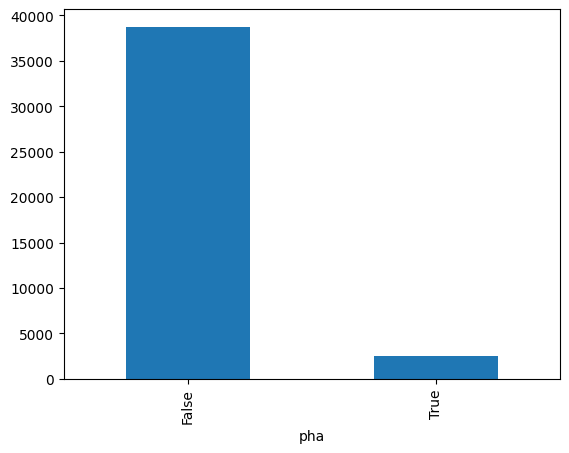

In [ ]:
nea_df_updated.pha.value_counts().plot(kind='bar')

nea_df_updated.pha.value_counts()

### As you can see this is a highly imbalance data. The reason is out so many asteroid that are known very few are pha.

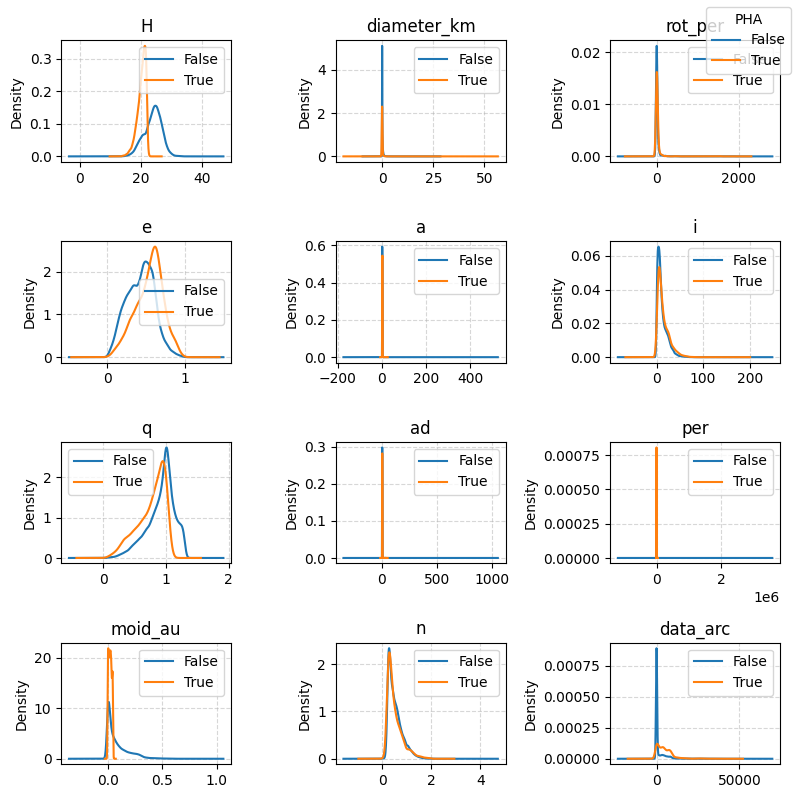

In [311]:
import math

cols = ['H', 'diameter_km', 'rot_per', 'e', 'a', 'i', 'q', 'ad', 'per', 'moid_au', 'n', 'data_arc']

n = len(cols)
ncols = 3  # number of columns in grid
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 2 * nrows))
axes = axes.flatten()  # flatten to 1D for easy looping

for i, col in enumerate(cols):
    nea_df_updated.groupby('pha')[col].plot(
        kind='density',
        ax=axes[i],
        legend=True
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Add a single shared legend (cleaner than repeating)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='PHA', loc='upper right')

plt.tight_layout()
plt.show()

This figure shows there are only few features that are different in pha and non pha asteroids.

So we will train our classifier on these features only.

In [395]:
features = ['H', 'e', 'i', 'q', 'moid_au', 'data_arc']
X = nea_df_updated[features]
y = nea_df_updated['pha']

X.isna().sum()

H             2
e             0
i             0
q             0
moid_au     131
data_arc    406
dtype: int64

In [396]:

true_indices = np.where(y)[0]
false_indices = np.where(~y)[0]
X.iloc[true_indices].isna().sum()
X.iloc[false_indices].isna().sum()

H             2
e             0
i             0
q             0
moid_au     131
data_arc    406
dtype: int64

We can drop the na values because all the na values are for non pha asteroids, and we have a lot of data for false values.

In [397]:
X = X.dropna() 
y = y[X.index]

Now we split the data into the train and test set. We are using the StratifiedShuffleSplit because we need to preserve the ratio of both classes (pha & non-pha). In a random split there is a high chance that we won't get the same ration because data is highly imbalanced.

In [398]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=0)

for train_idx, test_idx in splitter.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    

In [399]:
print(f'train df : {y_train.value_counts(normalize=True)}')
print('\n')
print(f'test df : {y_test.value_counts(normalize=True)}')

train df : pha
False    0.937688
True     0.062312
Name: proportion, dtype: float64


test df : pha
False    0.937661
True     0.062339
Name: proportion, dtype: float64


As we can see the percentage of both class is same in both set.

# First we try a simple logistics regression

In [400]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', random_state=1, max_iter=1000)
lr.fit(X_train, y_train)

preds = lr.predict(X_test)

For an unbalanced dataset like this accuracy is meaningless, so we will use other metrics like classification report and confusion matrix.

In [417]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("=== Logistics Regression ===\n")
print(f'Confusion Matrix \n{confusion_matrix(y_test, preds)}\n')
print(f'Classification Report \n{classification_report(y_test, preds)}\n')
print(f'Roc_auc Score \n{roc_auc_score(y_test, preds)}\n')

=== Logistics Regression ===

Confusion Matrix 
[[7210  512]
 [   5  503]]

Classification Report 
              precision    recall  f1-score   support

       False       1.00      0.93      0.97      7722
        True       0.50      0.99      0.66       508

    accuracy                           0.94      8230
   macro avg       0.75      0.96      0.81      8230
weighted avg       0.97      0.94      0.95      8230


Roc_auc Score 
0.9619267070054472



Looking at the confusion matrix we can see: The model 'over-warns' if an asteroid is pha. For 528 non pha it flagged them as pha. But it didn't wrongly flagged pha as non pha that much. So the model prioritize not giving false negative. Which is good but let's try Random forest and see if we can improve precision.

In [402]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rfc.fit(X_train, y_train)
preds_rf = rfc.predict(X_test)


In [403]:
print("Random Forest Classifier")
print(f'Confusion Matrix \n{confusion_matrix(y_test, preds_rf)}')
print(f'Classification Report \n{classification_report(y_test, preds_rf)}')
print(f'Roc_auc Score \n{roc_auc_score(y_test, preds_rf)}')

Random Forest Classifier
Confusion Matrix 
[[7633    8]
 [   3  505]]
Classification Report 
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      7641
        True       0.98      0.99      0.99       508

    accuracy                           1.00      8149
   macro avg       0.99      1.00      0.99      8149
weighted avg       1.00      1.00      1.00      8149

Roc_auc Score 
0.9965237524049188


The RandomForest classifier gives near perfect score. 

In [404]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rfc.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

    feature  importance
0         H    0.448639
4   moid_au    0.285253
5  data_arc    0.147647
3         q    0.082909
1         e    0.022828
2         i    0.012725


It gives importance to  mainly three fearures.

H : The absolute magnitude of the asteroid.

moid_au : The moid distance from earth.

data_arc : the difference between it's first observation to most recent. Meaning the asteroids with frequent observations are mor hazardous. This is intresting.

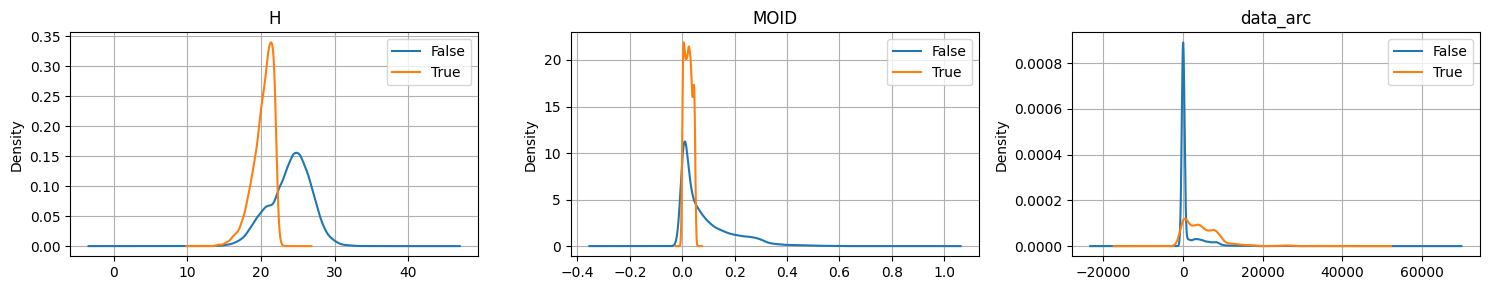

In [448]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
nea_df.groupby('pha')['H'].plot(kind='density', ax=axes[0], legend=True, title='H', grid=True)
nea_df.groupby('pha')['moid_au'].plot(kind='density', ax=axes[1], legend=True, title='MOID', grid=True)
nea_df.groupby('pha')['data_arc'].plot(kind='density', ax=axes[2], legend=True, title='data_arc', grid=True)
plt.tight_layout()
plt.show()

The NASA's definition of the pha requires H and moid of an asteroid. Our model captures them correctly. This demonstrates the model successfully learns the existing classification criteria rather than discovering new predictive patterns. However, it also captures data_arc as a deciding factor. This shouldn't be the case because how frequent scientists observe an asteroid doesn't determine it hazardousness. However, scientist will observe those asteroids more often it they knew it was pha. So, this feature is actually a data leakage.
So we have to remove it.

In [424]:
features_updated = ['H', 'e', 'i', 'q', 'moid_au']
X = nea_df_updated[features_updated]
y = nea_df_updated['pha']

X = X.dropna()
y = y[X.index]

In [425]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=0)

for train_idx, test_idx in splitter.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    

In [426]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rfc.fit(X_train, y_train)
preds_rf = rfc.predict(X_test)


In [427]:
print("Random Forest Classifier")
print(f'Confusion Matrix \n{confusion_matrix(y_test, preds_rf)}\n')
print(f'Classification Report: \n{classification_report(y_test, preds_rf)}\n')
print(f'Roc_auc Score \n{roc_auc_score(y_test, preds_rf)}\n')

Random Forest Classifier
Confusion Matrix 
[[7718    4]
 [   4  504]]

Classification Report: 
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      7722
        True       0.99      0.99      0.99       508

    accuracy                           1.00      8230
   macro avg       1.00      1.00      1.00      8230
weighted avg       1.00      1.00      1.00      8230


Roc_auc Score 
0.9958039918669839



In [428]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rfc.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

   feature  importance
0        H    0.594500
4  moid_au    0.291507
3        q    0.073316
1        e    0.024506
2        i    0.016171


The results are still the same the model classifies the asteroids correctly, by mainly using H and moid. It also uses q (the perihilion distance), sometimes to decide. This could be for the case when the moid is not very clear or falls on the boundary of pha.